In [1]:
#Імпорт бібліотек
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

ПІДГОТОВКА ДАНИХ

In [2]:
def load_and_preprocess_data(path='WineQT.csv'):
    df = pd.read_csv(path)
    X = df.drop(columns=['quality']).values
    y = df['quality'].values - df['quality'].min()

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    return X_train, y_train, X_val, y_val, X_test, y_test

CUSTOM MLP

In [3]:
class CustomMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, activations):
        super().__init__()
        layers = []
        sizes = [input_size] + hidden_sizes + [output_size]
        for i in range(len(sizes)-1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            if i < len(hidden_sizes):
                act = activations[i]
                if act == 'relu':
                    layers.append(nn.ReLU())
                elif act == 'tanh':
                    layers.append(nn.Tanh())
        self.model = nn.Sequential(*layers)

    def forward(self, X):
        return self.model(X)

НАВЧАННЯ

In [4]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=500, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        history['train_loss'].append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val)
            history['val_loss'].append(val_loss.item())

    return history

ВІЗУАЛІЗАЦІЯ

In [5]:
def plot_training_history(history_custom, history_pytorch=None):
    plt.figure(figsize=(10,5))
    plt.plot(history_custom['train_loss'], label='Custom MLP Train')
    plt.plot(history_custom['val_loss'], label='Custom MLP Val')
    if history_pytorch is not None:
        plt.plot(history_pytorch['train_loss'], label='PyTorch MLP Train')
        plt.plot(history_pytorch['val_loss'], label='PyTorch MLP Val')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_confusion_matrix(y_true, y_pred_custom, y_pred_pytorch=None):
    fig, axes = plt.subplots(1, 2 if y_pred_pytorch is not None else 1, figsize=(12,5))
    if y_pred_pytorch is not None:
        axes = axes.flatten()
    else:
        axes = [axes]

    cm_custom = confusion_matrix(y_true, y_pred_custom)
    sns.heatmap(cm_custom, annot=True, fmt='d', ax=axes[0])
    axes[0].set_title('Custom MLP')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    if y_pred_pytorch is not None:
        cm_pt = confusion_matrix(y_true, y_pred_pytorch)
        sns.heatmap(cm_pt, annot=True, fmt='d', ax=axes[1])
        axes[1].set_title('PyTorch MLP')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')

Custom MLP Accuracy: 0.6279
PyTorch MLP Accuracy: 0.5988


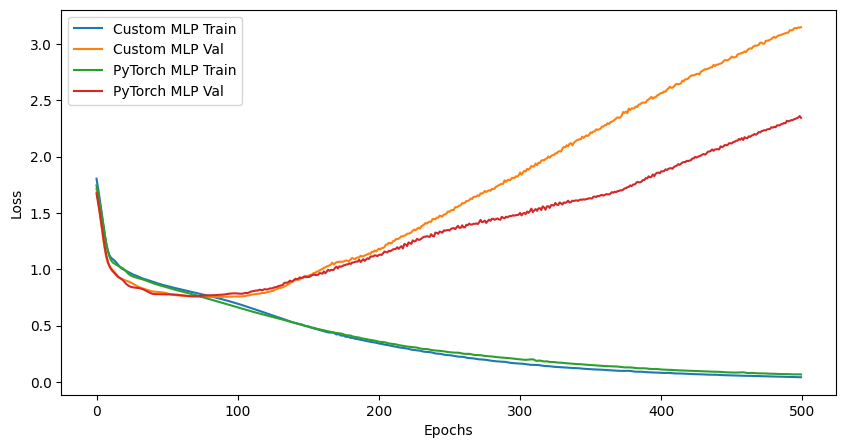

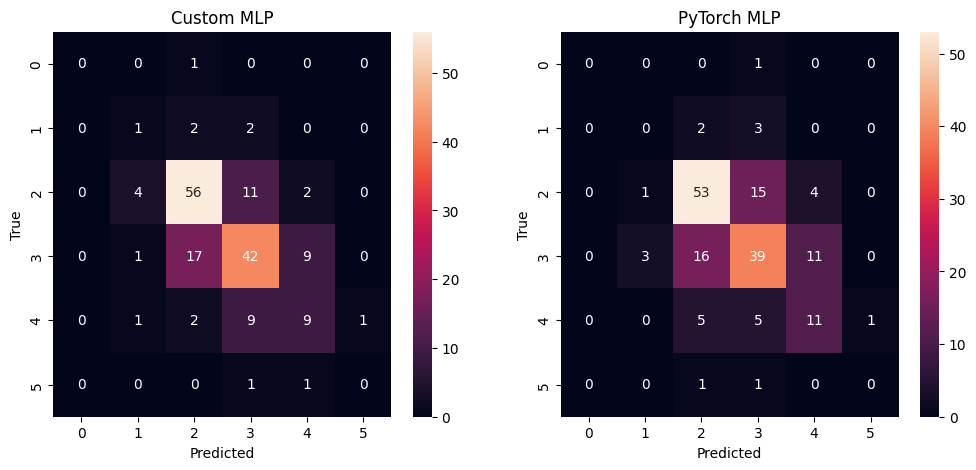

In [6]:
X_train, y_train, X_val, y_val, X_test, y_test = load_and_preprocess_data()

input_size = X_train.shape[1]
hidden_sizes = [32, 16]
output_size = len(torch.unique(y_train))
activations = ['relu', 'relu']

#Custom MLP
custom_model = CustomMLP(input_size, hidden_sizes, output_size, activations)
history_custom = train_model(custom_model, X_train, y_train, X_val, y_val, epochs=500, lr=0.01)

y_pred_custom = torch.argmax(custom_model(X_test), dim=1)
acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"Custom MLP Accuracy: {acc_custom:.4f}")

#PyTorch MLP
pytorch_model = CustomMLP(input_size, hidden_sizes, output_size, activations)
history_pytorch = train_model(pytorch_model, X_train, y_train, X_val, y_val, epochs=500, lr=0.01)
y_pred_pytorch = torch.argmax(pytorch_model(X_test), dim=1)
acc_pytorch = accuracy_score(y_test, y_pred_pytorch)
print(f"PyTorch MLP Accuracy: {acc_pytorch:.4f}")

#Візуалізація
plot_training_history(history_custom, history_pytorch)
plot_confusion_matrix(y_test, y_pred_custom, y_pred_pytorch)